In [ ]:
import pandas as pd
import yfinance as yf
from datetime import date, timedelta
import numpy as np

# define the time period for the data
end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")

# list of stock tickers to download
# BBD = BANCO BRADESCO, BDORY = Banco do Brasil, DNKEY = Danske Bank
# HDFCBANK.NS = HDFC Bank (Housing Development Finance Corporation, Indian Bank)
tickers = ['BDORY', 'BBD', 'DNKEY', 'HDFCBANK.NS']
tickers_bras = ['BDORY', 'BBD', 'ITUB', 'SAN']

data = yf.download(tickers_bras, group_by='Ticker', start=start_date, end=end_date, progress=False)

# reset index to bring Date into the columns for the melt function
stock_data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)
stock_data.reset_index(inplace=True)
stock_data.head()


YF.download() has changed argument auto_adjust default to True


<ipython-input-2-a0c2005d6794>:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stock_data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2024-03-26,BBD,2.585514,2.640721,2.585514,2.631520,7882800
1,2024-03-26,BDORY,5.311767,5.368985,5.311767,5.326071,111200
2,2024-03-26,ITUB,6.035471,6.124358,6.026582,6.115469,10325150
3,2024-03-26,SAN,4.576158,4.595305,4.557011,4.566585,2645100
4,2024-03-27,BBD,2.613117,2.686726,2.594715,2.677525,21241300


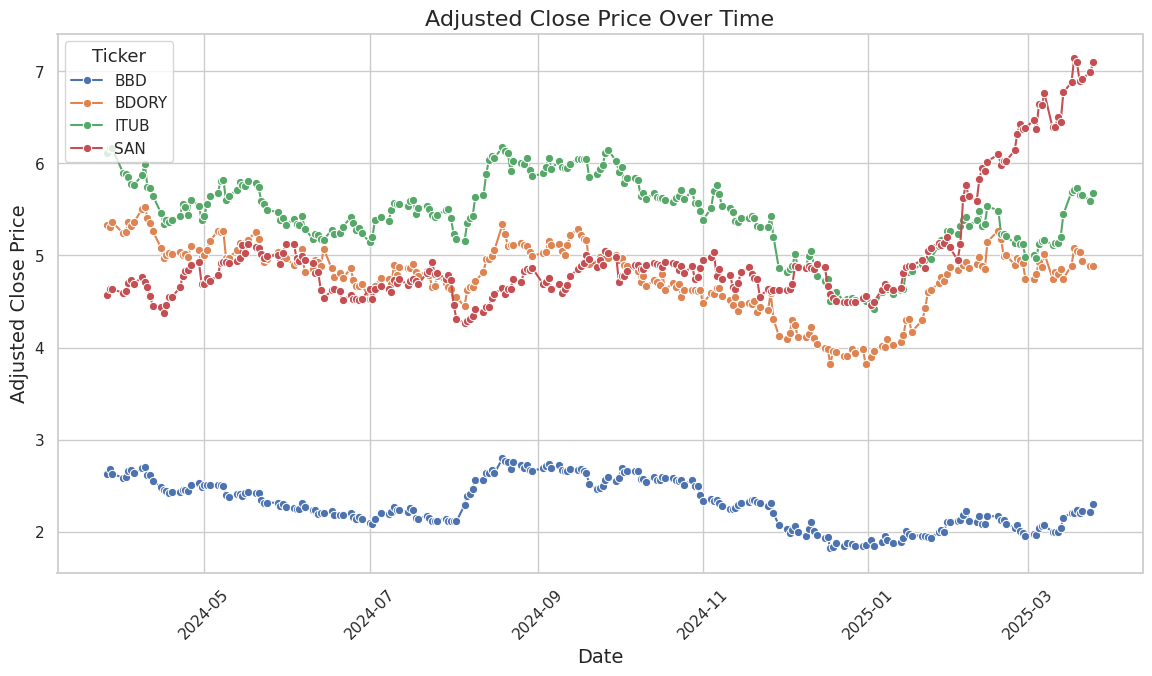

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

stock_data['Date'] = pd.to_datetime(stock_data['Date'])

stock_data.set_index('Date', inplace=True)
stock_data.reset_index(inplace=True)
plt.figure(figsize=(14, 7))
sns.set(style='whitegrid')

sns.lineplot(data=stock_data, x='Date', y='Close', hue='Ticker', marker='o')

plt.title('Adjusted Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Adjusted Close Price', fontsize=14)
plt.legend(title='Ticker', title_fontsize='13', fontsize='11')
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

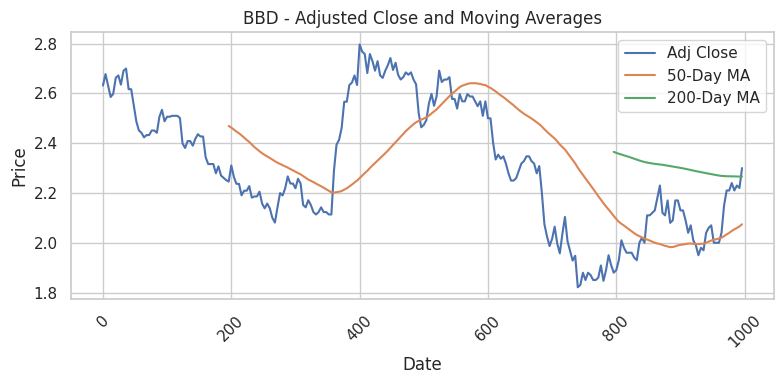

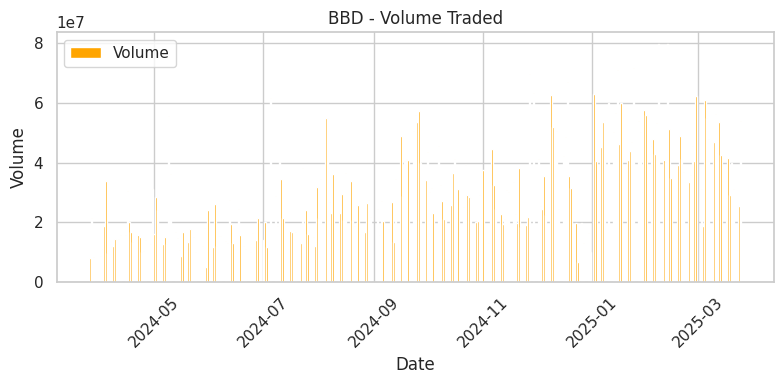

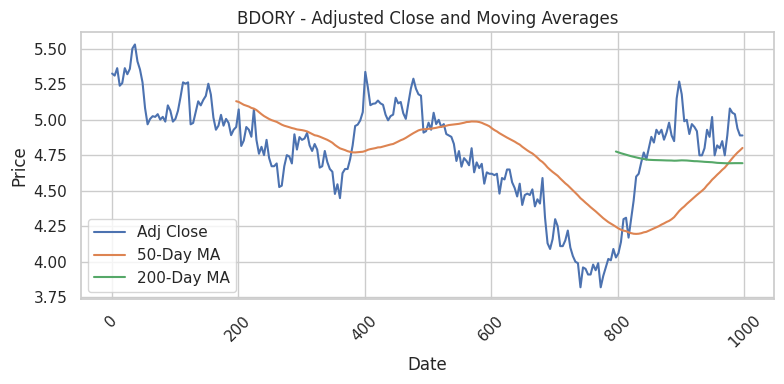

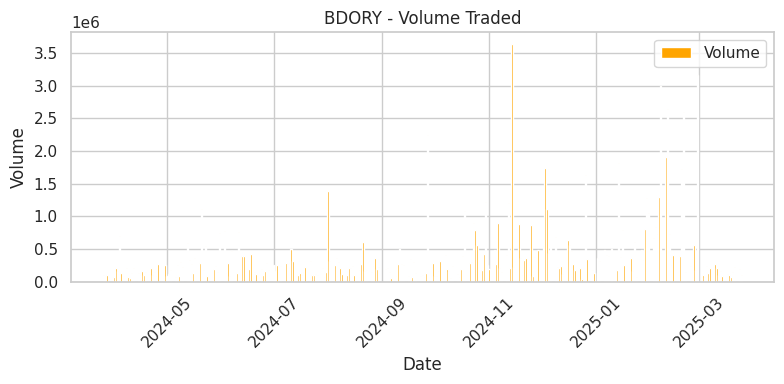

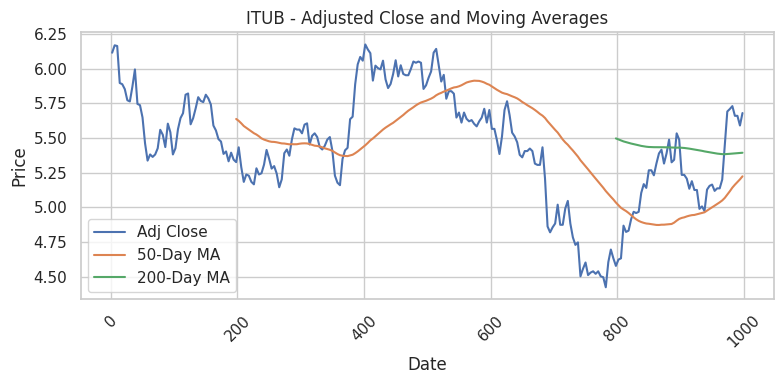

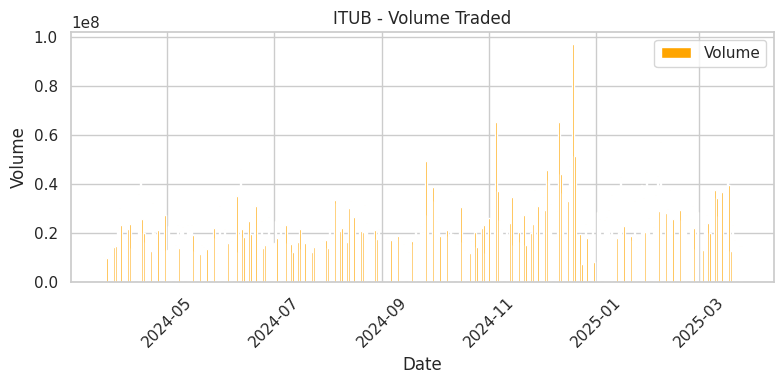

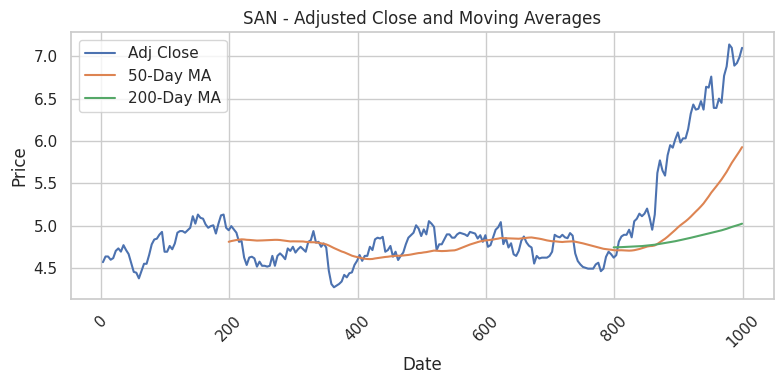

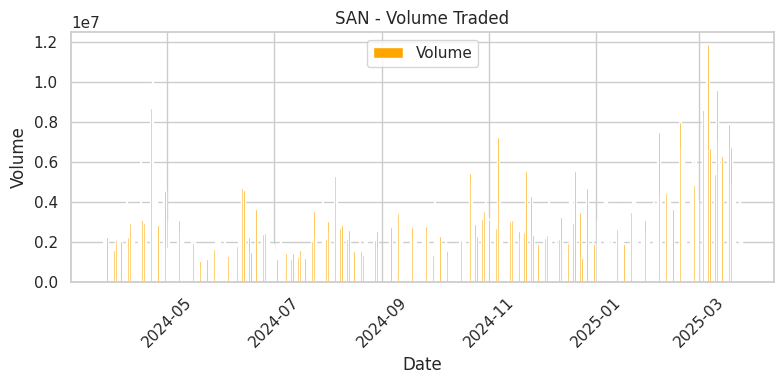

In [ ]:
short_window = 50
long_window = 200

unique_tickers = stock_data['Ticker'].unique()


for ticker in unique_tickers:
    ticker_data = stock_data[stock_data['Ticker'] == ticker].copy()
    ticker_data = ticker_data[~ticker_data.isnull()]
    ticker_data['50_MA'] = ticker_data['Close'].rolling(window=short_window).mean()
    ticker_data['200_MA'] = ticker_data['Close'].rolling(window=long_window).mean()

    plt.figure(figsize=(8, 4))
    plt.plot(ticker_data.index, ticker_data['Close'], label='Adj Close')
    plt.plot(ticker_data.index, ticker_data['50_MA'], label='50-Day MA')
    plt.plot(ticker_data.index, ticker_data['200_MA'], label='200-Day MA')
    plt.title(f'{ticker} - Adjusted Close and Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    ticker_data = ticker_data.reset_index()

    plt.figure(figsize=(8, 4))
    plt.bar(ticker_data['Date'], ticker_data['Volume'], label='Volume', color='orange') # Modified

    plt.title(f'{ticker} - Volume Traded')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

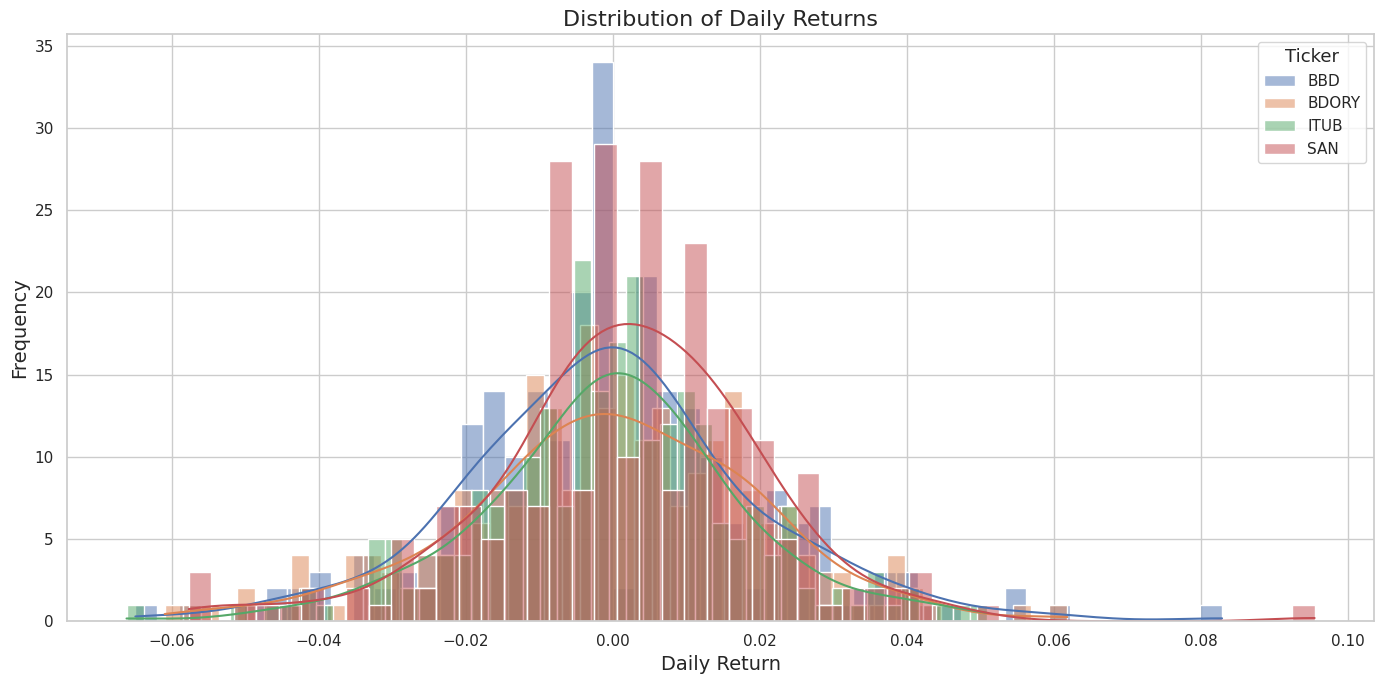

In [ ]:
stock_data['Daily Return'] = stock_data.groupby('Ticker')['Close'].pct_change()

plt.figure(figsize=(14, 7))
sns.set(style='whitegrid')

for ticker in unique_tickers:
    ticker_data = stock_data[stock_data['Ticker'] == ticker]
    sns.histplot(ticker_data['Daily Return'].dropna(), bins=50, kde=True, label=ticker, alpha=0.5)

plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Ticker', title_fontsize='13', fontsize='11')
plt.grid(True)
plt.tight_layout()
plt.show()

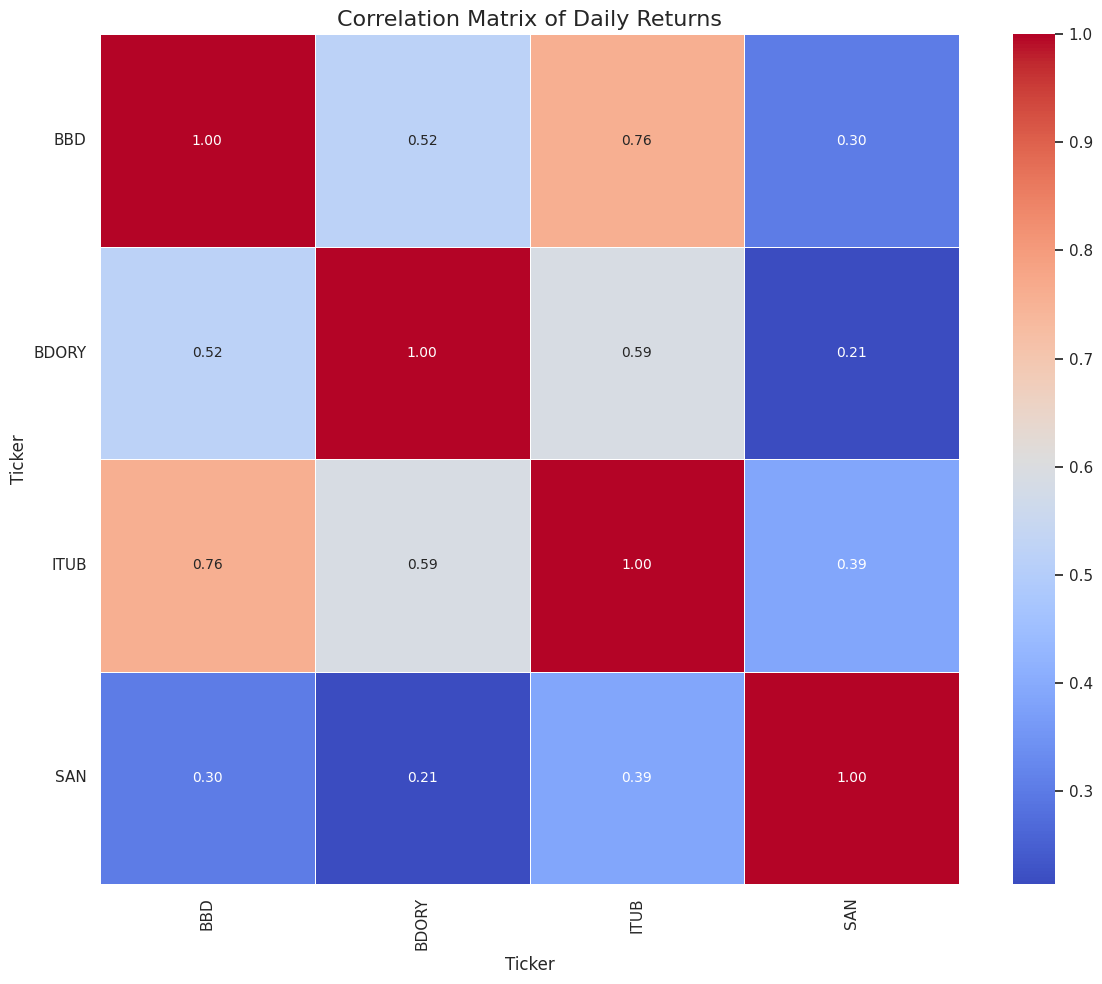

In [ ]:
daily_returns = stock_data.pivot_table(index='Date', columns='Ticker', values='Daily Return')
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(12, 10))
sns.set(style='whitegrid')

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5, fmt='.2f', annot_kws={"size": 10})
plt.title('Correlation Matrix of Daily Returns', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

expected_returns = daily_returns.mean() * 252  # annualize the returns
volatility = daily_returns.std() * np.sqrt(252)  # annualize the volatility

stock_stats = pd.DataFrame({
    'Expected Return': expected_returns,
    'Volatility': volatility
})

stock_stats

,Expected Return,Volatility
Ticker,,
BBD,-0.084289,0.323405
BDORY,-0.035979,0.317812
ITUB,-0.035497,0.280352
SAN,0.491452,0.298826


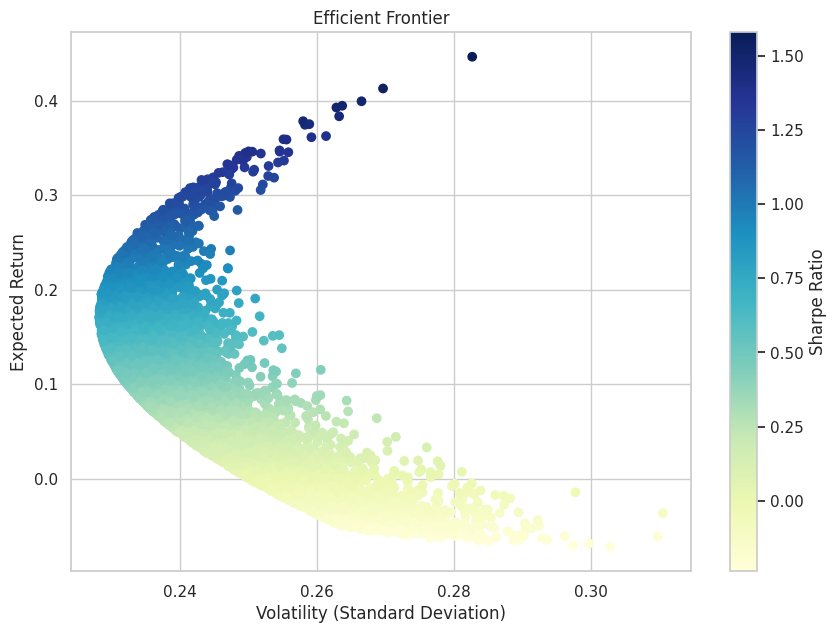

In [ ]:
# function to calculate portfolio performance
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.dot(weights, returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility

# number of portfolios to simulate
num_portfolios = 10000

# arrays to store the results
results = np.zeros((3, num_portfolios))

# annualized covariance matrix
cov_matrix = daily_returns.cov() * 252

np.random.seed(42)

for i in range(num_portfolios):
    weights = np.random.random(len(unique_tickers))
    weights /= np.sum(weights)

    portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = portfolio_return / portfolio_volatility  # Sharpe Ratio

plt.figure(figsize=(10, 7))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='YlGnBu', marker='o')
plt.title('Efficient Frontier')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()

In [ ]:
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_ratio = results[2, max_sharpe_idx]

print(' Max Expected Return: ',(max_sharpe_return * 100), '\n',
      'Max Volatility: ', (max_sharpe_volatility * 100),'\n',
      'Max Sharpe Ratio: ', max_sharpe_ratio)

 Max Expected Return:  44.63468617982874 
 Max Volatility:  28.268533786011858 
 Max Sharpe Ratio:  1.5789529983304391


In [ ]:
max_sharpe_weights = np.zeros(len(unique_tickers))

for i in range(num_portfolios):
    weights = np.random.random(len(unique_tickers))
    weights /= np.sum(weights)

    portfolio_return, portfolio_volatility = portfolio_performance(weights, expected_returns, cov_matrix)

    if results[2, i] == max_sharpe_ratio:
        max_sharpe_weights = weights * 100
        break

portfolio_weights_df = pd.DataFrame({
    'Ticker': unique_tickers,
    'Weight': max_sharpe_weights
})

portfolio_weights_df

,Ticker,Weight
0,BBD,19.024476
1,BDORY,20.855109
2,ITUB,33.220471
3,SAN,26.899943
